In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
fraud=pd.read_csv("fraudDetection.csv")

In [ ]:
fraud

In [ ]:
# Remove double qoute
for qoute in fraud.select_dtypes(include="object"):
    fraud[qoute]=fraud[qoute].str.replace("'","",regex=False).str.strip()

In [ ]:
fraud

In [ ]:
# remove Qoute and white space
fraud['category']=fraud['category'].str.replace("es_","").str.strip()

In [43]:
fraud

,step,customer,age,gender,zipcodeOri,merchant,zipMerchant,category,amount,fraud
0,0,C1093826151,4,M,28007,M348934600,28007,transportation,4.55,0
1,0,C352968107,2,M,28007,M348934600,28007,transportation,39.68,0
2,0,C2054744914,4,F,28007,M1823072687,28007,transportation,26.89,0
3,0,C1760612790,3,M,28007,M348934600,28007,transportation,17.25,0
4,0,C757503768,5,M,28007,M348934600,28007,transportation,35.72,0
...,...,...,...,...,...,...,...,...,...,...
594638,179,C1753498738,3,F,28007,M1823072687,28007,transportation,20.53,0
594639,179,C650108285,4,F,28007,M1823072687,28007,transportation,50.73,0
594640,179,C123623130,2,F,28007,M349281107,28007,fashion,22.44,0
594641,179,C1499363341,5,M,28007,M1823072687,28007,transportation,14.46,0


In [44]:
# check null values
fraud.isnull().sum()

step           0
customer       0
age            0
gender         0
zipcodeOri     0
merchant       0
zipMerchant    0
category       0
amount         0
fraud          0
dtype: int64

In [45]:
fraud.describe()

,step,amount,fraud
count,594643.000000,594643.000000,594643.000000
mean,94.986827,37.890135,0.012108
std,51.053632,111.402831,0.109369
min,0.000000,0.000000,0.000000
25%,52.000000,13.740000,0.000000
50%,97.000000,26.900000,0.000000
75%,139.000000,42.540000,0.000000
max,179.000000,8329.960000,1.000000


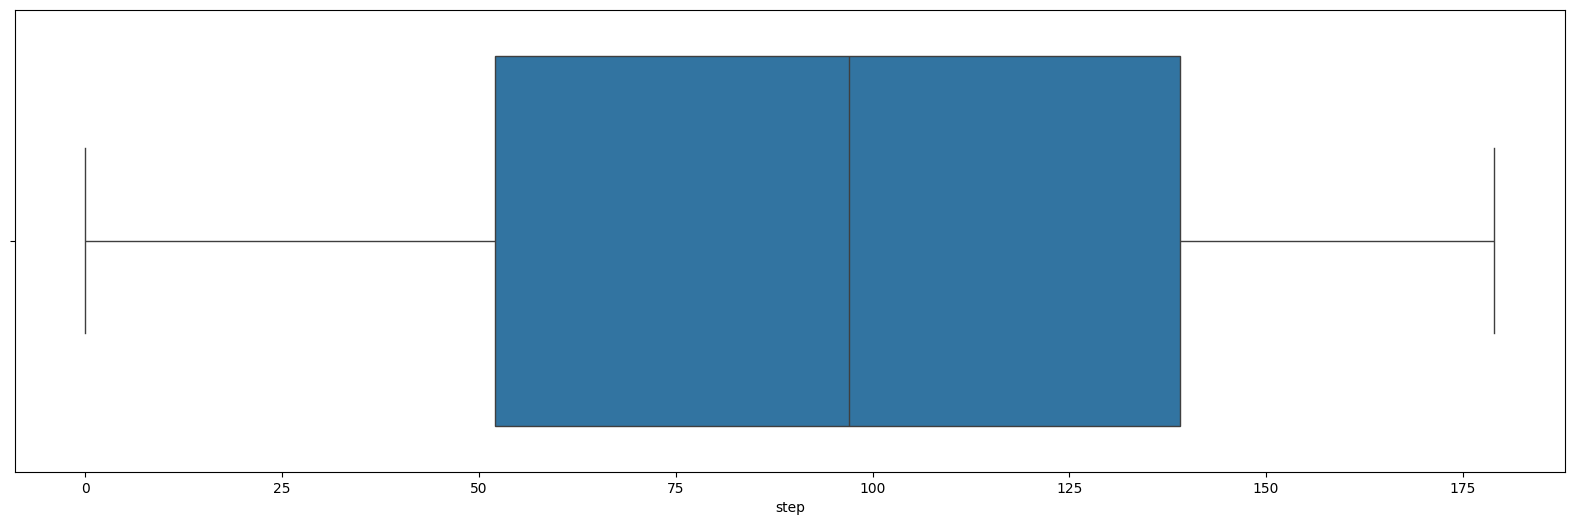

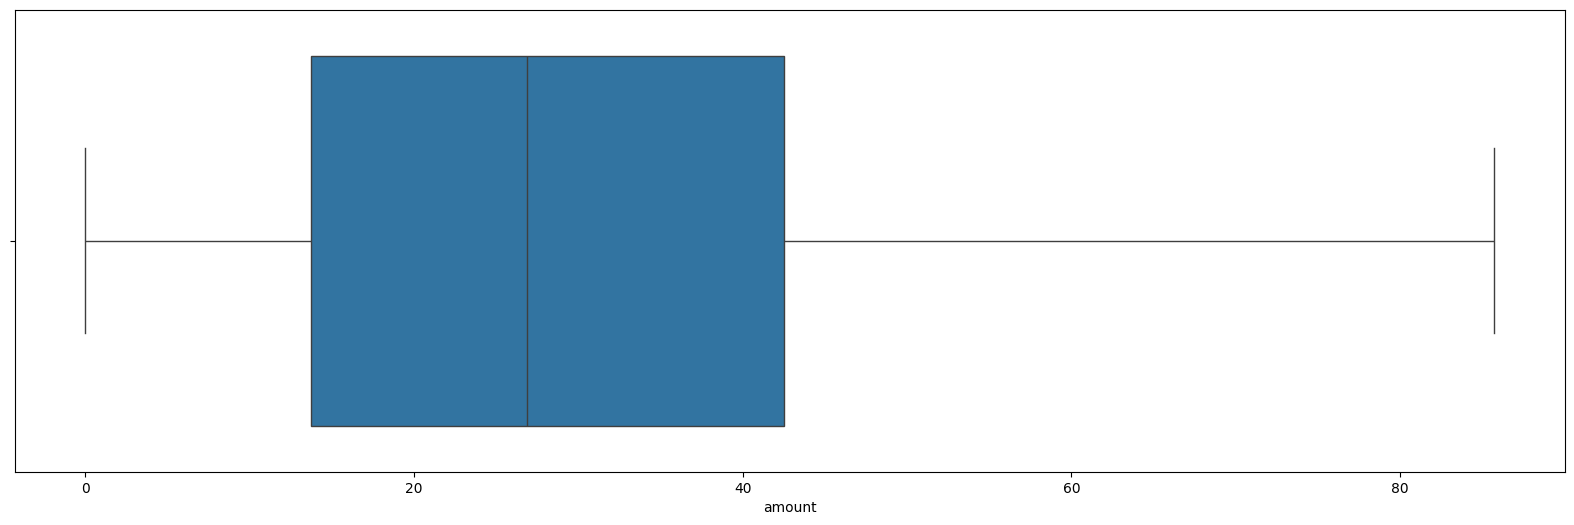

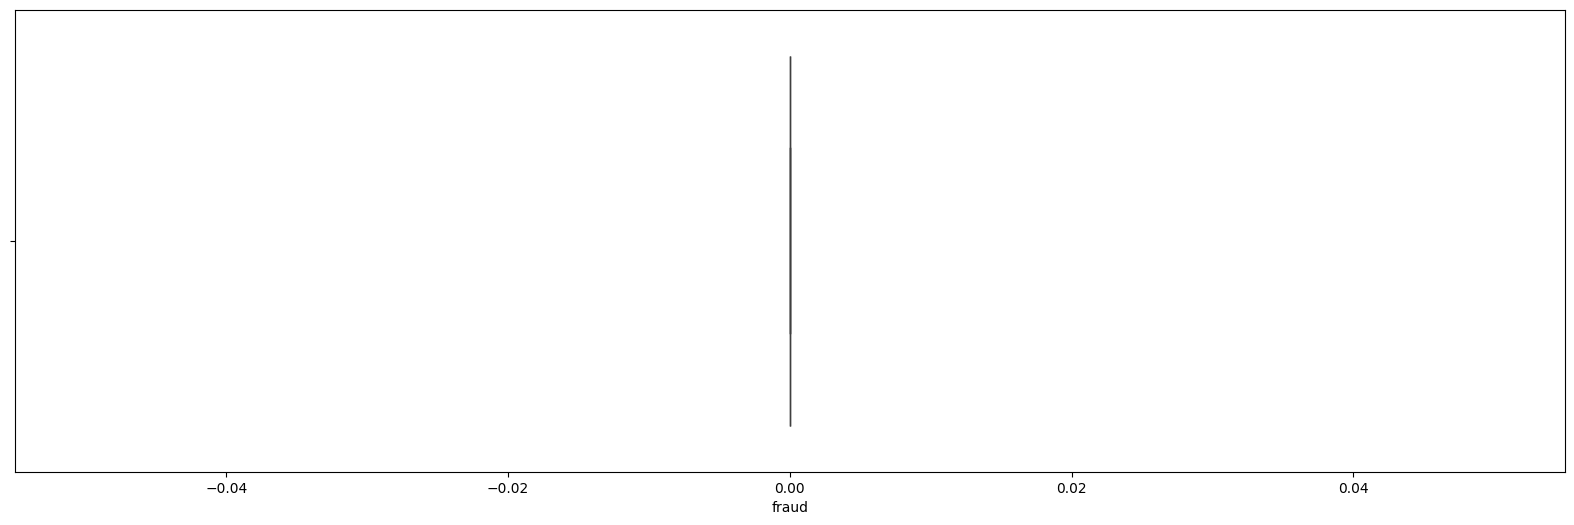

In [55]:
# chek outliers
for outliers in fraud.columns:
    if fraud[outliers].dtype!="object":
        plt.figure(figsize=(20,6))
        sns.boxplot(x=fraud[outliers])

In [54]:
# handle outliers
for handleOut in fraud.columns:
    if fraud[handleOut].dtype!="object":
        Q1=fraud[handleOut].quantile(0.25)
        Q3=fraud[handleOut].quantile(0.75)
        IQR=Q3-Q1

        Upper=Q3+1.5*IQR
        Lower=Q1-1.5*IQR

        

        count=fraud[(fraud[handleOut]<Lower) | (fraud[handleOut]>Upper)].shape[0]
        if count!=0:
            fraud[handleOut]=fraud[handleOut].clip(lower=Lower,upper=Upper)

In [58]:
# check skewness
for skew in fraud.columns:
    if fraud[skew].dtype!="object":
        skewness=fraud[skew].skew()
        print(f"{skew}  {skewness}")

step  -0.1194282196127338
amount  0.8468415947963844
fraud  0.0


In [ ]:
# split data
